## TREINAMENTO - REDE NEURAL

In [9]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### CARREGAR DADOS PROCESSADOS

In [10]:
X_train = pd.read_csv('/content/drive/MyDrive/X_train_proc.csv')
X_test  = pd.read_csv('/content/drive/MyDrive/X_test_proc.csv')

y_train = pd.read_csv('/content/drive/MyDrive/y_train.csv').squeeze()
y_test  = pd.read_csv('/content/drive/MyDrive/y_test.csv').squeeze()

# Para a rodada 2: treino + teste1 juntos
X_train2 = pd.concat([X_train, X_test], ignore_index=True)
y_train2 = pd.concat([y_train, y_test], ignore_index=True)

# teste2 - carregar separado
X_test2 = pd.read_csv('/content/drive/MyDrive/X_test2_proc.csv')
y_test2 = pd.read_csv('/content/drive/MyDrive/y_test2.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_test1 : {X_test.shape}')
print(f'X_train2: {X_train2.shape}  <- treino + teste1')
print(f'X_test2 : {X_test2.shape}')
print(f'\nDesbalanceamento — Taxa de abandono: {y_train.mean()*100:.1f}%')

# peso para classe minoritária
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: n_neg / n_pos}
print(f'Class weights: {class_weight}')

X_train : (450105, 24)
X_test1 : (112527, 24)
X_train2: (562632, 24)  ← treino + teste1
X_test2 : (631, 24)

Desbalanceamento — Taxa de abandono: 19.4%
Class weights: {0: 1.0, 1: np.float64(4.149766026337769)}



# MÉTRICAS DE AVALIAÇÃO

### **ACURÁCIA:** NÃO será usada como métrica principal pois o dataset é
### desbalanceado (~19% de abandono). Um modelo que prevê sempre "não abandona"
### já teria ~81% de acurácia sem aprender nada útil.

# Métricas escolhidas:

### **RECALL (Sensibilidade):** métrica mais importante para este problema.
### Queremos minimizar falsos negativos - pacientes que vão abandonar mas
### o modelo não detecta. No contexto clínico, deixar de identificar um
### paciente em risco é mais grave do que um falso alarme.

### **PRECISÃO:** proporção de pacientes sinalizados que realmente abandonam.
### Importante para não sobrecarregar a equipe de saúde com falsos alertas.

### **F1-SCORE:** média harmônica entre precisão e recall. Métrica principal
### pois equilibra os dois trade-offs acima no contexto desbalanceado.

### **ROC-AUC:** mede a capacidade discriminativa geral do modelo independente
### do threshold. Útil para comparar os dois modelos entre si.


### FUNÇÃO DE AVALIAÇÃO

In [11]:
def avaliar(nome, y_true, y_pred, y_prob):
    print(f'\n{"="*50}')
    print(f' {nome}')
    print(f'{"="*50}')
    print(classification_report(y_true, y_pred))
    print(f'ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0])
    axes[0].set_title(f'Matriz de Confusão - {nome}')
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1])
    axes[1].set_title(f'Curva ROC - {nome}')
    plt.tight_layout()
    plt.show()

### DEFINIÇÃO DO MODELO

In [12]:
def criar_modelo(n_features):
    modelo = keras.Sequential([
        keras.Input(shape=(n_features,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1,  activation='sigmoid'),
    ])
    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return modelo

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### RODADA 1: treino -> teste1

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6724 - loss: 1.0773 - val_accuracy: 0.6374 - val_loss: 0.6690
Epoch 2/100
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6899 - loss: 1.0173 - val_accuracy: 0.6948 - val_loss: 0.6068
Epoch 3/100
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6938 - loss: 1.0060 - val_accuracy: 0.7409 - val_loss: 0.5549
Epoch 4/100
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6963 - loss: 0.9900 - val_accuracy: 0.7218 - val_loss: 0.5716
Epoch 5/100
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6997 - loss: 0.9877 - val_accuracy: 0.5867 - val_loss: 0.7693
Epoch 6/100
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.7029 - loss: 0.9722 - val_accuracy: 0.6997 - val_loss: 0.6042
Epoch 7/100
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7026 - loss: 0.9697 - val_accuracy: 0.7442 - val_loss: 0.5476
Epoch 8/100
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 

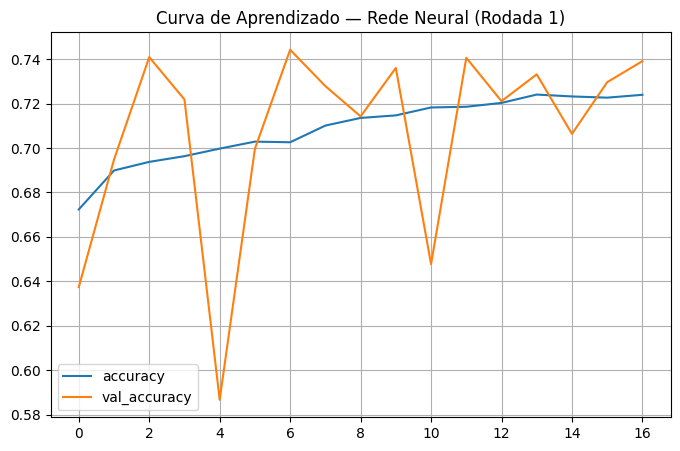

3517/3517 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step

 Rede Neural — Teste 1
              precision    recall  f1-score   support

           0       0.89      0.77      0.82     90676
           1       0.39      0.61      0.47     21851

    accuracy                           0.74    112527
   macro avg       0.64      0.69      0.65    112527
weighted avg       0.79      0.74      0.76    112527

ROC-AUC: 0.7503


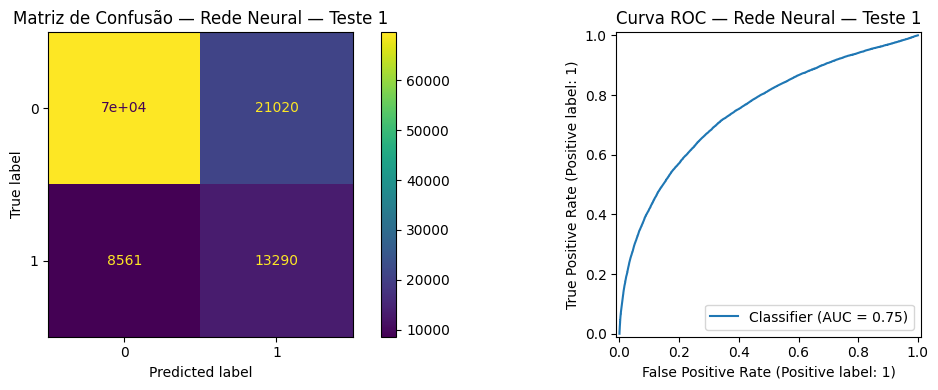

In [13]:
modelo_RN = criar_modelo(X_train.shape[1])
modelo_RN.summary()

history = modelo_RN.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot(figsize=(8, 5))
plt.title('Curva de Aprendizado — Rede Neural (Rodada 1)')
plt.grid(True)
plt.show()

prob_RN_test1 = modelo_RN.predict(X_test).flatten()
pred_RN_test1 = (prob_RN_test1 >= 0.5).astype(int)
avaliar('Rede Neural - Teste 1', y_test, pred_RN_test1, prob_RN_test1)

### RODADA 2: treino + teste1 -> teste2

Epoch 1/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.6668 - loss: 1.1451 - val_accuracy: 0.6905 - val_loss: 0.6098
Epoch 2/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.6838 - loss: 1.0443 - val_accuracy: 0.6010 - val_loss: 0.7477
Epoch 3/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.6916 - loss: 1.0054 - val_accuracy: 0.6472 - val_loss: 0.6854
Epoch 4/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.6945 - loss: 0.9954 - val_accuracy: 0.7137 - val_loss: 0.5865
Epoch 5/100
1978/1978 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.7014 - loss: 0.9735 - val_accuracy: 0.7313 - val_loss: 0.5655


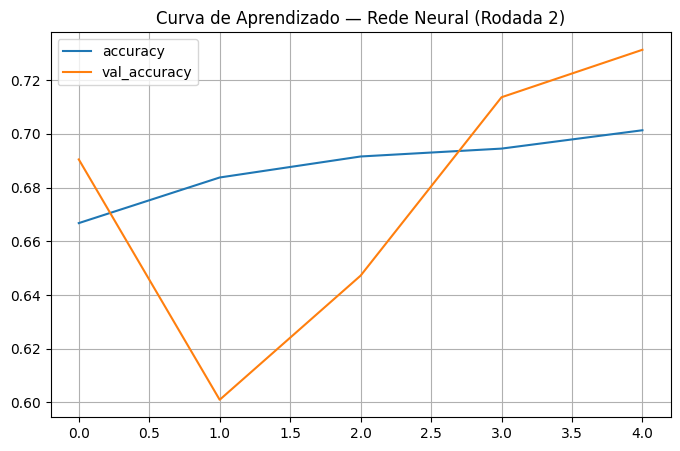

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Rede Neural — Teste 2
              precision    recall  f1-score   support

           0       0.22      0.02      0.04       193
           1       0.69      0.97      0.81       438

    accuracy                           0.68       631
   macro avg       0.46      0.49      0.42       631
weighted avg       0.55      0.68      0.57       631

ROC-AUC: 0.4114


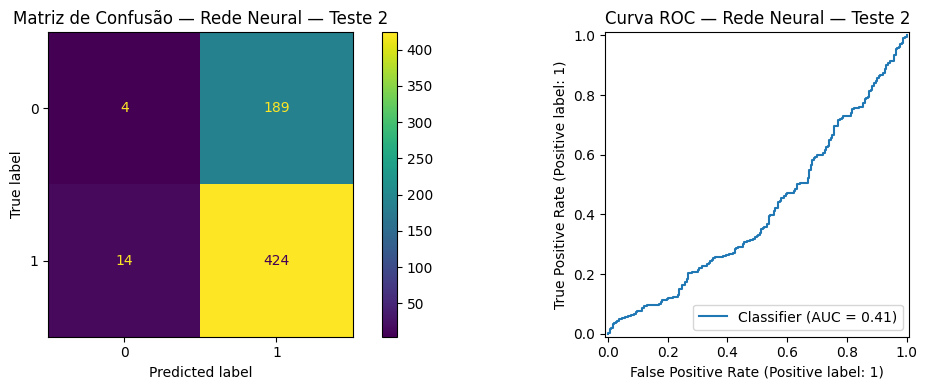

In [14]:
modelo_RN2 = criar_modelo(X_train2.shape[1])

history2 = modelo_RN2.fit(
    X_train2, y_train2,
    epochs=100,
    batch_size=256,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

pd.DataFrame(history2.history)[['accuracy', 'val_accuracy']].plot(figsize=(8, 5))
plt.title('Curva de Aprendizado - Rede Neural (Rodada 2)')
plt.grid(True)
plt.show()

prob_RN_test2 = modelo_RN2.predict(X_test2).flatten()
pred_RN_test2 = (prob_RN_test2 >= 0.5).astype(int)
avaliar('Rede Neural - Teste 2', y_test2, pred_RN_test2, prob_RN_test2)

### EXPLICABILIDADE - PERMUTATION IMPORTANCE


Calculando Permutation Importance...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━

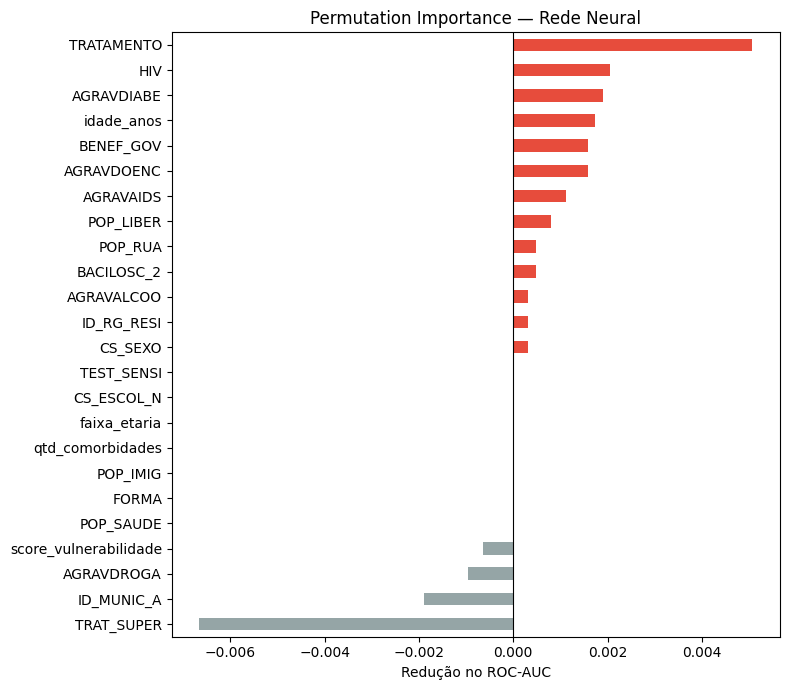


Top features relevantes: ['TRATAMENTO', 'HIV', 'AGRAVDIABE', 'idade_anos', 'BENEF_GOV', 'AGRAVDOENC', 'AGRAVAIDS', 'POP_LIBER', 'POP_RUA', 'BACILOSC_2']


In [16]:
from sklearn.utils.estimator_checks import parametrize_with_checks
from sklearn.utils.multiclass import check_classification_targets

class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
        self._estimator_type = "classifier"
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X).flatten() >= 0.5).astype(int)
    def predict_proba(self, X):
        p = self.model.predict(X).flatten()
        return np.column_stack([1-p, p])

print('\nCalculando Permutation Importance...')
result = permutation_importance(
    KerasWrapper(modelo_RN2), X_test2, y_test2,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

importancias = pd.Series(result.importances_mean, index=X_train.columns).sort_values()

plt.figure(figsize=(8, 7))
importancias.plot(kind='barh', color=importancias.map(lambda v: '#e74c3c' if v > 0 else '#95a5a6'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Permutation Importance — Rede Neural', fontsize=12)
plt.xlabel('Redução no ROC-AUC')
plt.tight_layout()
plt.show()

top_features = importancias[importancias > 0].sort_values(ascending=False).head(10).index.tolist()
print(f'\nTop features relevantes: {top_features}')

In [21]:
teste2 = pd.read_csv('/content/drive/MyDrive/teste2.csv', low_memory=False)
print(teste2.shape)
print(teste2['ltfu'].value_counts())

(631, 101)
ltfu
1    438
0    193
Name: count, dtype: int64


### SALVAR MODELOS

In [17]:
modelo_RN2.save('/content/drive/MyDrive/modelo_RN.keras')
joblib.dump(top_features, '/content/drive/MyDrive/top_features_RN.pkl')
print('modelo_RN.keras salvo!')

modelo_RN.keras salvo!
